In [2]:
import re
import os

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from plotly.colors import sample_colorscale

# Reading files from the directory

In [3]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/ppi_different_bits/ppi_relu_quantized_results_for_appendix_7.csv
/kaggle/input/ppi_different_bits/ppi_relu_quantized_results_for_appendix_6.csv
/kaggle/input/ppi_different_bits/ppi_relu6_quantized_results_for_appendix_5.csv
/kaggle/input/ppi_different_bits/ppi_softplus_quantized_results_for_appendix_8.csv
/kaggle/input/ppi_different_bits/ppi_softplus_quantized_results_for_appendix_2.csv
/kaggle/input/ppi_different_bits/ppi_softplus_quantized_results_for_appendix_32.csv
/kaggle/input/ppi_different_bits/ppi_elu_quantized_results_for_appendix_7.csv
/kaggle/input/ppi_different_bits/ppi_gelu_quantized_results_for_appendix_5.csv
/kaggle/input/ppi_different_bits/ppi_silu_quantized_results_for_appendix_32.csv
/kaggle/input/ppi_different_bits/ppi_relu6_quantized_results_for_appendix_32.csv
/kaggle/input/ppi_different_bits/ppi_relu6_quantized_results_for_appendix_4.csv
/kaggle/input/ppi_different_bits/ppi_sigmoid_quantized_results_for_appendix_16.csv
/kaggle/input/ppi_different_bit

## [Reading data] Creating a file_path variable for convenience 

In [4]:
file_path = "/kaggle/input/ppi_different_bits/"

# Information about the data

The experimental part of this article is based on the article Barcelo et al. in which the authors focused on the aggregate-combine graph neural networks (AC-GNNs) and aggregate-combine-readout GNNs (ACR-GNNs)

**Paper**: [The Logical Expressiveness of Graph Neural Networks](https://openreview.net/forum?id=r1lZ7AEKvB)  
**Code**: [GNN-logic GitHub Repository](https://github.com/juanpablos/GNN-logic.git)  


# Activation functions

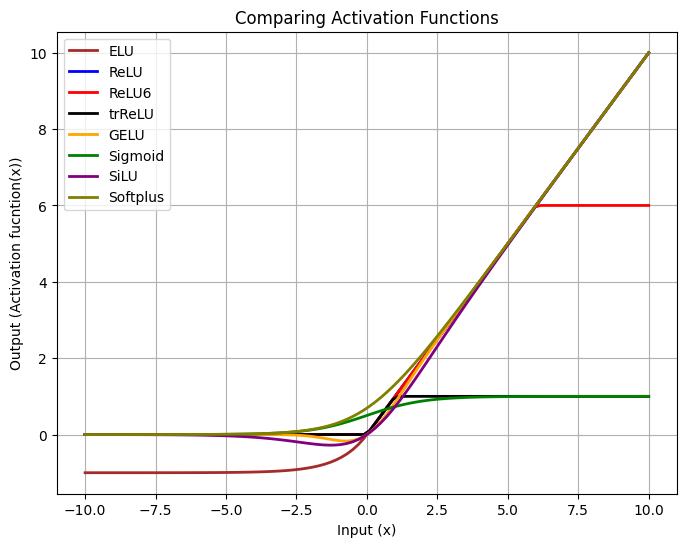

In [5]:
x = torch.linspace(-10, 10, 100)
elu=nn.ELU()
relu=nn.ReLU()
relu6=nn.ReLU6()
hardtanh = nn.Hardtanh(0, 1)
gelu=nn.GELU()
sigmoid = nn.Sigmoid()
silu=nn.SiLU()
softplus=nn.Softplus()
plt.figure(figsize=(8, 6))

plt.plot(x.numpy(), elu(x).numpy(), label="ELU", color="brown", linewidth=2)
plt.plot(x.numpy(), relu(x).numpy(), label="ReLU", color="blue", linewidth=2)
plt.plot(x.numpy(), relu6(x).numpy(), label="ReLU6", color="red", linewidth=2)
plt.plot(x.numpy(), hardtanh(x).numpy(), label="trReLU", color="black", linewidth=2)
plt.plot(x.numpy(), gelu(x).numpy(), label="GELU", color="orange", linewidth=2)
plt.plot(x.numpy(), sigmoid(x).numpy(), label="Sigmoid", color="green", linewidth=2)
plt.plot(x.numpy(), silu(x).numpy(), label="SiLU", color="purple", linewidth=2)
plt.plot(x.numpy(), softplus(x).numpy(), label="Softplus", color="olive", linewidth=2)

plt.xlabel("Input (x)")
plt.ylabel("Output (Activation fucntion(x))")
plt.title("Comparing Activation Functions")
plt.legend()
plt.grid(True)
#plt.savefig('all_plus_ELU.png')
plt.show()


# Read the data from the files

In [6]:
# Path 
data_path = f"{file_path}"

# Collect all .csv files in the folder
csv_files = [f for f in os.listdir(data_path) if f.endswith(".csv")]

# Read them into a dictionary of DataFrames
dfs_dptq_different_bits = {os.path.splitext(f)[0]: pd.read_csv(os.path.join(data_path, f)) for f in csv_files}

for name, df in dfs_dptq_different_bits.items():
    print(f"{name}: {df.shape}")

ppi_relu_quantized_results_for_appendix_7: (3, 10)
ppi_relu_quantized_results_for_appendix_6: (3, 10)
ppi_relu6_quantized_results_for_appendix_5: (3, 10)
ppi_softplus_quantized_results_for_appendix_8: (10, 10)
ppi_softplus_quantized_results_for_appendix_2: (10, 10)
ppi_softplus_quantized_results_for_appendix_32: (10, 10)
ppi_elu_quantized_results_for_appendix_7: (3, 10)
ppi_gelu_quantized_results_for_appendix_5: (3, 10)
ppi_silu_quantized_results_for_appendix_32: (10, 10)
ppi_relu6_quantized_results_for_appendix_32: (10, 10)
ppi_relu6_quantized_results_for_appendix_4: (10, 10)
ppi_sigmoid_quantized_results_for_appendix_16: (10, 10)
ppi_relu_quantized_results_for_appendix_2: (12, 10)
ppi_relu_quantized_results_for_appendix_5: (3, 10)
ppi_silu_quantized_results_for_appendix_6: (3, 10)
ppi_relu_quantized_results_for_appendix_4: (12, 10)
ppi_relu_quantized_results_for_appendix_16: (12, 10)
ppi_gelu_quantized_results_for_appendix_8: (9, 10)
ppi_softplus_quantized_results_for_appendix_7: (3,

In [7]:
dfs_dptq_different_bits['ppi_sigmoid_quantized_results_for_appendix_32']

,Layers,Train_Loss_quantized,Train_Acc_quantized,Elapsed_Time_Train_quantized,Test_Loss_quantized,Test_Acc_quantized,Elapsed_Time_Test_quantized,Val_Loss_quantized,Val_Acc_quantized,Elapsed_Time_Val_quantized
0,1,0.498377,0.548394,0.968,3.021227,0.409007,0.123,3.992330,0.427304,0.148
1,2,0.470242,0.604197,1.101,1.253182,0.448295,0.164,1.339449,0.399287,0.191
2,3,0.405988,0.659967,1.333,0.740542,0.367642,0.172,0.896653,0.440037,0.201
3,4,0.467501,0.611323,2.223,0.924853,0.451801,0.290,0.808229,0.479380,0.353
4,5,0.466728,0.614209,1.968,1.911162,0.428861,0.243,1.525251,0.443294,0.287
5,6,0.470026,0.608549,1.973,1.938406,0.464861,0.267,4.363400,0.435373,0.297
6,7,0.470646,0.610068,2.279,0.912505,0.476086,0.291,0.934228,0.466151,0.357
7,8,0.470106,0.611972,2.552,1.299890,0.458088,0.326,1.385718,0.447377,0.404
8,9,0.472565,0.602734,2.651,0.985661,0.477359,0.373,0.776798,0.482912,0.418
9,10,0.473369,0.603319,2.930,1.341234,0.418015,0.390,1.294717,0.416626,0.458


In [8]:
options_of_activations = ["relu", "relu6", "trrelu", "gelu", "sigmoid", "silu", "softplus", "elu"]
bitwidths = [32, 16, 8,7,6,5, 4, 2]

for activation in options_of_activations:
    for bits in bitwidths:
        
        key = f"ppi_{activation}_quantized_results_for_appendix_{bits}"
        
        # Check if key exists
        if key not in dfs_dptq_different_bits:
            print(f"Skipping: {key} — not found in dictionary.")
            continue

        dfs_dptq_different_bits[key]


In [9]:
options_of_activations = ["relu", "relu6", "trrelu", "gelu", "sigmoid", "silu", "softplus", "elu"]
bitwidths = [32, 16, 8, 4, 2]


# --- Stable color map for h (works with many unique values) ---viridis
if len(bitwidths) == 1:
    color_map = {bitwidths[0]: px.colors.sample_colorscale("viridis", [0.5])[0]}
else:
    # normalize positions 0..1 along a colorscale
    positions = {h: i/(len(bitwidths)-1) for i, h in enumerate(bitwidths)}
    color_map = {h: sample_colorscale("viridis", [positions[h]])[0] for h in bitwidths}

splits = [
    ("Train", "Train_Acc_quantized"),
    ("Test", "Test_Acc_quantized"),
    ("Validation", "Val_Acc_quantized"),
]


for activation in options_of_activations:

    fig = make_subplots(
        rows=1,
        cols=len(splits),
        subplot_titles=[name for (name, _) in splits],
        shared_yaxes=True
    )

    for col_idx, (split_name, col_name) in enumerate(splits, start=1):

        for bits in bitwidths:
            key = f"ppi_{activation}_quantized_results_for_appendix_{bits}"
            if key not in dfs_dptq_different_bits:
                continue

            df = dfs_dptq_different_bits[key][
                ["Layers", "Train_Acc_quantized", "Test_Acc_quantized", "Val_Acc_quantized"]
            ]

            df_sel = df.copy()
            if df_sel.empty:
                continue

            df_sel = df_sel.sort_values("Layers")

            fig.add_trace(
                go.Scatter(
                    x=df_sel["Layers"],
                    y=df_sel[col_name],
                    mode="lines+markers",
                    name=f"{bits} bits",
                    legendgroup=f"{bits}bits",
                    line=dict(color=color_map[bits], width=2),
                    marker=dict(color=color_map[bits]),
                    showlegend=(col_idx == len(splits))  # only show legend on last subplot
                ),
                row=1,
                col=col_idx
            )

    fig.update_layout(
        title=dict(
            text=fr"ACR-GNN | Activation = {activation.capitalize()}",
            y=0.95,
            font=dict(size=20)
        ),
        margin=dict(t=120),
        legend_title="Bit-width"
    )


    for i in range(len(splits)):
        fig.update_xaxes(title_text="Layers (L)", row=1, col=i+1)

    fig.update_yaxes(title_text="Micro Accuracy", row=1, col=1)

    fig.show()


In [10]:
options_of_activations = ["relu", "relu6", "trrelu", "gelu", "sigmoid", "silu", "softplus", "elu"]
bitwidths = [32, 16, 8,7,6,5, 4, 2]


# --- Stable color map for h (works with many unique values) ---viridis
if len(bitwidths) == 1:
    color_map = {bitwidths[0]: px.colors.sample_colorscale("viridis", [0.5])[0]}
else:
    # normalize positions 0..1 along a colorscale
    positions = {h: i/(len(bitwidths)-1) for i, h in enumerate(bitwidths)}
    color_map = {h: sample_colorscale("viridis", [positions[h]])[0] for h in bitwidths}

splits = [
    ("Train", "Train_Acc_quantized"),
    ("Test", "Test_Acc_quantized"),
    ("Validation", "Val_Acc_quantized"),
]


for activation in options_of_activations:

    fig = make_subplots(
        rows=1,
        cols=len(splits),
        subplot_titles=[name for (name, _) in splits],
        shared_yaxes=True
    )

    for col_idx, (split_name, col_name) in enumerate(splits, start=1):

        for bits in bitwidths:
            key = f"ppi_{activation}_quantized_results_for_appendix_{bits}"
            if key not in dfs_dptq_different_bits:
                continue

            df = dfs_dptq_different_bits[key][
                ["Layers", "Train_Acc_quantized", "Test_Acc_quantized", "Val_Acc_quantized"]
            ]

            df_sel = df[df["Layers"] < 4].copy()
            if df_sel.empty:
                continue

            df_sel = df_sel.sort_values("Layers")

            fig.add_trace(
                go.Scatter(
                    x=df_sel["Layers"],
                    y=df_sel[col_name],
                    mode="lines+markers",
                    name=f"{bits} bits",
                    legendgroup=f"{bits}bits",
                    line=dict(color=color_map[bits], width=2),
                    marker=dict(color=color_map[bits]),
                    showlegend=(col_idx == len(splits))  # only show legend on last subplot
                ),
                row=1,
                col=col_idx
            )

    fig.update_layout(
        title=dict(
            text=fr"ACR-GNN | Activation = {activation.capitalize()}",
            y=0.95,
            font=dict(size=20)
        ),
        margin=dict(t=120),
        legend_title="Bit-width"
    )


    for i in range(len(splits)):
        fig.update_xaxes(title_text="Layers (L)", row=1, col=i+1)

    fig.update_yaxes(title_text="Micro Accuracy", row=1, col=1)

    fig.show()


In [11]:
options_of_activations = ["relu", "relu6", "trrelu", "gelu","sigmoid", "silu", "softplus", "elu"]
bitwidths = [32, 16, 8, 7, 6, 5, 4, 2]

splits = [
    ("Train", "Train_Acc_quantized"),
    ("Test", "Test_Acc_quantized"),
    ("Validation", "Val_Acc_quantized"),
]

rows = []

for activation in options_of_activations:
    for bits in bitwidths:
        key = f"ppi_{activation}_quantized_results_for_appendix_{bits}"
        if key not in dfs_dptq_different_bits:
            continue

        df = dfs_dptq_different_bits[key][
            ["Layers", "Train_Acc_quantized", "Test_Acc_quantized", "Val_Acc_quantized"]
        ].copy()

        # filter classifier
        df_sel = df[df["Layers"] < 4].copy()

        if df_sel.empty:
            continue

        for _, row in df_sel.iterrows():
            layer = int(row["Layers"])

            for split_name, col_name in splits:
                acc = float(row[col_name])
                rows.append({
                    "activation": activation,
                    "bitwidth": bits,
                    "split": split_name,
                    "layer": layer,
                    "accuracy": acc,
                })

df_all = pd.DataFrame(rows)

df_all = df_all.sort_values(
    ["activation", "split", "layer", "bitwidth"]
)
df_all


,activation,bitwidth,split,layer,accuracy
604,elu,2,Test,1,0.340007
595,elu,4,Test,1,0.399131
586,elu,5,Test,1,0.399963
577,elu,6,Test,1,0.397626
568,elu,7,Test,1,0.399432
...,...,...,...,...,...
224,trrelu,6,Validation,3,0.392651
215,trrelu,7,Validation,3,0.383966
206,trrelu,8,Validation,3,0.373476
197,trrelu,16,Validation,3,0.390481


In [12]:
output_dir = "splits_pivot"
os.makedirs(output_dir, exist_ok=True)

for split_name, col_name in [
    ("Train", "Train_Acc_quantized"),
    ("Test", "Test_Acc_quantized"),
    ("Validation", "Val_Acc_quantized")
]:
    df_split = df_all[df_all["split"] == split_name].copy()
    if df_split.empty:
        print(f"No data for {split_name}")
        continue

    pivot = df_split.pivot_table(
        index=["activation", "layer"],
        columns="bitwidth",
        values="accuracy"
    )

    filename = f"{output_dir}/{split_name.lower()}_pivot.csv"
    pivot.to_csv(filename)
    print(f"Saved {filename}")


Saved splits_pivot/train_pivot.csv
Saved splits_pivot/test_pivot.csv
Saved splits_pivot/validation_pivot.csv


In [13]:
pivot_files = {
    "Train": "splits_pivot/train_pivot.csv",
    "Test": "splits_pivot/test_pivot.csv",
    "Validation": "splits_pivot/validation_pivot.csv",
}

THRESHOLD = 0    

all_drops = []

for split_name, filepath in pivot_files.items():
    df = pd.read_csv(filepath)
    df.reset_index(drop=True, inplace=True)

    for idx, row in df.iterrows():
        for i in range(len(bitwidths)-1):
            b1 = bitwidths[i]
            b2 = bitwidths[i+1]

            if str(b1) not in df.columns or str(b2) not in df.columns:
                continue

            a1 = row[str(b1)]
            a2 = row[str(b2)]

            # skip if missing
            if pd.isna(a1) or pd.isna(a2):
                continue

            drop = a2 - a1

            if drop < -THRESHOLD:  # ANY drop
                all_drops.append({
                    "split": split_name,
                    "activation": row["activation"],
                    "layer": row["layer"],
                    "from_bits": b1,
                    "to_bits": b2,
                    "acc_from": a1,
                    "acc_to": a2,
                    "drops": drop
                })

df_drops = pd.DataFrame(all_drops)
df_drops


,split,activation,layer,from_bits,to_bits,acc_from,acc_to,drops
0,Train,elu,1,32,16,0.570802,0.570800,-0.000002
1,Train,elu,1,8,7,0.574004,0.570662,-0.003341
2,Train,elu,1,6,5,0.570698,0.569550,-0.001147
3,Train,elu,1,5,4,0.569550,0.566370,-0.003181
4,Train,elu,1,4,2,0.566370,0.484844,-0.081526
...,...,...,...,...,...,...,...,...
281,Validation,trrelu,2,8,7,0.397522,0.386461,-0.011061
282,Validation,trrelu,2,7,6,0.386461,0.385731,-0.000729
283,Validation,trrelu,2,5,4,0.397716,0.394320,-0.003396
284,Validation,trrelu,3,16,8,0.390481,0.373476,-0.017004


In [14]:
for activation_selected in ["relu", "relu6", "trrelu", "gelu","sigmoid", "silu", "softplus", "elu"]:
    print(df_drops[(df_drops.activation == activation_selected) & (df_drops.from_bits > 4)& (df_drops.drops < -0.01) ][['split', 'activation',  'layer',  'from_bits',  'to_bits','drops'  ]])

          split activation  layer  from_bits  to_bits     drops
148        Test       relu      1         32       16 -0.010267
149        Test       relu      1          7        6 -0.027213
154        Test       relu      3         32       16 -0.013466
156        Test       relu      3          5        4 -0.032393
232  Validation       relu      2         16        8 -0.015078
    split activation  layer  from_bits  to_bits     drops
46  Train      relu6      1          8        7 -0.011276
53  Train      relu6      2          5        4 -0.012176
          split activation  layer  from_bits  to_bits     drops
195        Test     trrelu      1         32       16 -0.026129
196        Test     trrelu      1          7        6 -0.023775
197        Test     trrelu      1          5        4 -0.013549
199        Test     trrelu      2         16        8 -0.029678
201        Test     trrelu      2          6        5 -0.012522
202        Test     trrelu      2          5        4 -0.0

In [17]:
for activation_selected in ["relu", "relu6", "trrelu", "gelu","sigmoid", "silu", "softplus", "elu"]:
    print('\\begin{table}[h!]')
    print('\\centering')
    print('\\caption{PPI. Accuracy drops across bit-width reductions for the', activation_selected,'activation function}')
    print('\\label{tab:ppi-bitwidth-drops-',activation_selected,'}')
    print(df_drops[(df_drops.activation == activation_selected) & (df_drops.from_bits > 4)& (df_drops.drops < -0.01) ][['split', 'activation',  'layer',  'from_bits',  'to_bits','drops'  ]].to_latex(index=False))
    print('\\end{table}\n')

\begin{table}[h!]
\centering
\caption{PPI. Accuracy drops across bit-width reductions for the relu activation function}
\label{tab:ppi-bitwidth-drops- relu }
\begin{tabular}{llrrrr}
\toprule
split & activation & layer & from_bits & to_bits & drops \\
\midrule
Test & relu & 1 & 32 & 16 & -0.010267 \\
Test & relu & 1 & 7 & 6 & -0.027213 \\
Test & relu & 3 & 32 & 16 & -0.013466 \\
Test & relu & 3 & 5 & 4 & -0.032393 \\
Validation & relu & 2 & 16 & 8 & -0.015078 \\
\bottomrule
\end{tabular}

\end{table}

\begin{table}[h!]
\centering
\caption{PPI. Accuracy drops across bit-width reductions for the relu6 activation function}
\label{tab:ppi-bitwidth-drops- relu6 }
\begin{tabular}{llrrrr}
\toprule
split & activation & layer & from_bits & to_bits & drops \\
\midrule
Train & relu6 & 1 & 8 & 7 & -0.011276 \\
Train & relu6 & 2 & 5 & 4 & -0.012176 \\
\bottomrule
\end{tabular}

\end{table}

\begin{table}[h!]
\centering
\caption{PPI. Accuracy drops across bit-width reductions for the trrelu activatio